# 02 · Exploratory analysis of TYK2 bioactivity data

First look at the TYK2 (`CHEMBL3553`) inhibitor dataset from ChEMBL 37: how much data there is,
how potent it is, what the compounds look like, and how they're distributed across chemical space.

**Inputs** (run `src/get_chembl_data.py` then `src/process_activities.py` first):
- `data/raw/tyk2_activities_raw.csv` — one row per activity measurement
- `data/processed/tyk2_compounds.csv` — one row per standardised compound (median pChEMBL + descriptors)

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.manifold import TSNE

RDLogger.DisableLog("rdApp.*")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

ACTIVE_THRESHOLD = 7.0  # pChEMBL >= 7 (<= 100 nM), matches process_activities.py

In [2]:
# Plot style: thin marks, recessive axes, fixed colour roles
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY = "#8a8984"
TEXT, TEXT_2 = "#0b0b0b", "#52514e"

DOMAIN_COLORS = {"JH2": BLUE, "JH1": ORANGE, "Other": GREY}
ACTIVITY_COLORS = {"Active": BLUE, "Inactive": ORANGE}
POTENCY_CMAP = LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"]
)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": TEXT_2,
    "axes.edgecolor": "#c9c8c3",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#ecebe7",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": TEXT_2,
    "ytick.color": TEXT_2,
    "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

In [3]:
raw = pd.read_csv(ROOT / "data/raw/tyk2_activities_raw.csv")
compounds = pd.read_csv(ROOT / "data/processed/tyk2_compounds.csv")

# Same record-level filter as process_activities.py (drops values re-cited from earlier papers)
records = raw[raw["potential_duplicate"] == 0].copy()


def domain_from_text(desc):
    d = str(desc).lower()
    if "jh2" in d or "pseudokinase" in d:
        return "JH2"
    if "jh1" in d or "kinase domain" in d or "catalytic domain" in d:
        return "JH1"
    return "Other"


def primary_domain(domains):
    s = set(str(domains).split(","))
    if s == {"JH2"}:
        return "JH2"
    if s == {"JH1"}:
        return "JH1"
    return "Other"  # unspecified, or measured against both domains


records["domain"] = records["assay_description"].map(domain_from_text)
compounds["domain"] = compounds["domains"].map(primary_domain)
compounds["activity_class"] = np.where(compounds["active"] == 1, "Active", "Inactive")

print(f"Raw records:        {len(raw):>6}")
print(f"Filtered records:   {len(records):>6}")
print(f"Unique compounds:   {len(compounds):>6}")
print(f"Assays:             {records['assay_chembl_id'].nunique():>6}")
print(f"Source documents:   {records['document_chembl_id'].nunique():>6}")
compounds.head()

Raw records:         10313
Filtered records:     6880
Unique compounds:     5913
Assays:                394
Source documents:      266


,smiles_std,molecule_chembl_id,pchembl_median,pchembl_std,n_measurements,standard_types,domains,binned_only,pchembl_measured,n_measured,...,logp,hbd,hba,tpsa,rot_bonds,heavy_atoms,lipinski_violations,ligand_efficiency,domain,activity_class
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,CHEMBL3918308,7.335,1.774838,2,IC50,unspecified,False,7.335,2,...,3.2743,1,3,58.87,2,20,0,0.502448,Other,Active
1,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,CHEMBL3927649,6.820,NaN,1,IC50,unspecified,False,6.820,1,...,3.7477,1,4,62.11,3,26,0,0.359362,Other,Inactive
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,CHEMBL3979340,7.010,NaN,1,IC50,unspecified,False,7.010,1,...,3.3407,1,5,75.25,3,25,0,0.384148,Other,Active
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,CHEMBL3967749,6.960,NaN,1,IC50,unspecified,False,6.960,1,...,3.8092,1,5,62.11,3,25,0,0.381408,Other,Inactive
4,Brc1ncc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,CHEMBL3931093,6.960,NaN,1,IC50,unspecified,False,6.960,1,...,3.2042,1,6,75.00,3,25,0,0.381408,Other,Inactive


## 2. Dataset overview

In [4]:
overview = pd.DataFrame({
    "records": records["standard_type"].value_counts(),
    "compounds": records.groupby("standard_type")["molecule_chembl_id"].nunique(),
})
print(overview, "\n")
print("Compounds by primary assay domain:")
print(compounds["domain"].value_counts().to_string(), "\n")
print("Measurements per compound:")
print(compounds["n_measurements"].value_counts().sort_index().head(8).to_string())

               records  compounds
standard_type                    
IC50              4036       3372
Kd                1794       1697
Ki                1050        952 

Compounds by primary assay domain:
domain
Other    3546
JH2      1961
JH1       406 

Measurements per compound:
n_measurements
1    5266
2     510
3      97
4      23
5       7
6       1
7       1
9       3


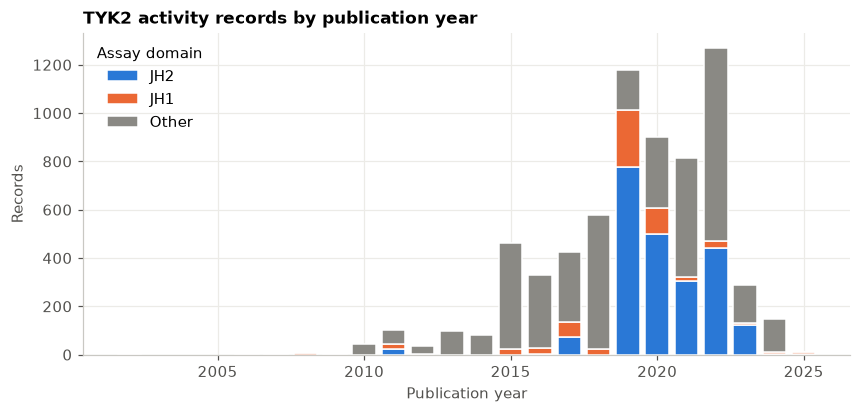

Earliest record: 2002, latest: 2025
Share of compounds first reported since 2018: 75%


In [5]:
# New compounds and records per publication year
first_year = records.groupby("molecule_chembl_id")["document_year"].min()
by_year = (
    records.dropna(subset=["document_year"])
    .groupby(["document_year", "domain"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["JH2", "JH1", "Other"], fill_value=0)
)
by_year.index = by_year.index.astype(int)

fig, ax = plt.subplots(figsize=(9, 3.8))
bottom = np.zeros(len(by_year))
for dom in by_year.columns:
    ax.bar(by_year.index, by_year[dom], bottom=bottom, width=0.8,
           color=DOMAIN_COLORS[dom], label=dom, edgecolor="white", linewidth=1)
    bottom += by_year[dom].values
ax.set_title("TYK2 activity records by publication year")
ax.set_xlabel("Publication year")
ax.set_ylabel("Records")
ax.legend(title="Assay domain", loc="upper left")
save(fig, "02_records_by_year")
plt.show()

print(f"Earliest record: {by_year.index.min()}, latest: {by_year.index.max()}")
print(f"Share of compounds first reported since 2018: {(first_year >= 2018).mean():.0%}")

## 3. Potency distribution

pChEMBL = −log₁₀(molar IC50/Ki/Kd). A value of 7 is 100 nM, 8 is 10 nM, 9 is 1 nM.

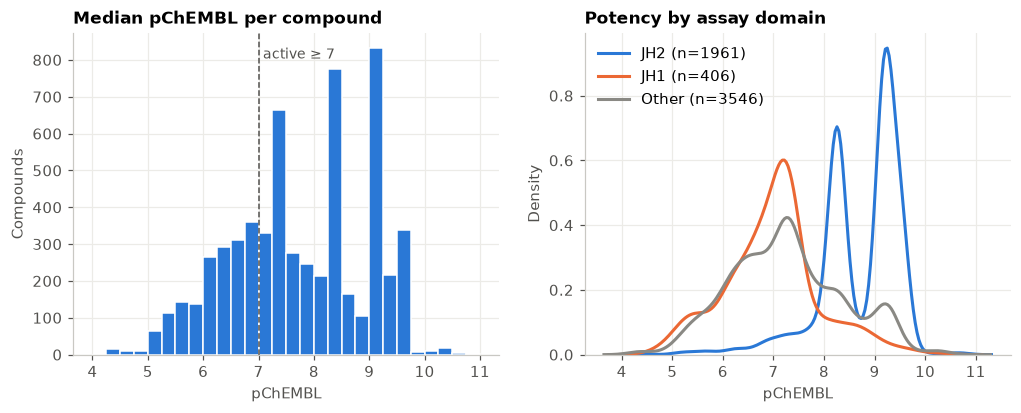

         count  mean   std   min   25%   50%   75%    max
domain                                                   
JH1      406.0  6.98  0.93  4.62  6.40  7.26  7.26  10.29
JH2     1961.0  8.72  0.78  4.50  8.26  9.12  9.22  10.80
Other   3546.0  7.26  1.11  4.30  6.48  7.26  8.00  10.64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.hist(compounds["pchembl_median"], bins=np.arange(4, 11.25, 0.25),
        color=BLUE, edgecolor="white", linewidth=1)
ax.axvline(ACTIVE_THRESHOLD, color=TEXT_2, linestyle="--", linewidth=1)
ax.text(ACTIVE_THRESHOLD + 0.08, ax.get_ylim()[1] * 0.92,
        f"active ≥ {ACTIVE_THRESHOLD:g}", color=TEXT_2, fontsize=9)
ax.set_title("Median pChEMBL per compound")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Compounds")

ax = axes[1]
for dom in ["JH2", "JH1", "Other"]:
    vals = compounds.loc[compounds["domain"] == dom, "pchembl_median"]
    sns.kdeplot(vals, ax=ax, color=DOMAIN_COLORS[dom], linewidth=2,
                label=f"{dom} (n={len(vals)})")
ax.set_title("Potency by assay domain")
ax.set_xlabel("pChEMBL")
ax.legend()
save(fig, "02_potency_distribution")
plt.show()

print(compounds.groupby("domain")["pchembl_median"].describe().round(2))

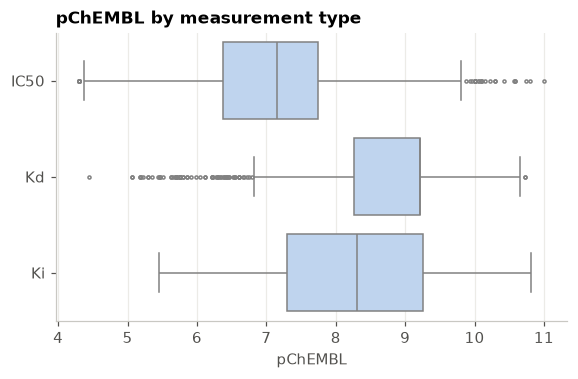

In [7]:
# Potency by measurement type (record level)
fig, ax = plt.subplots(figsize=(6, 3.4))
order = records["standard_type"].value_counts().index
sns.boxplot(data=records, x="pchembl_value", y="standard_type", order=order,
            color="#b7d3f6", linewidth=1, fliersize=2, ax=ax)
ax.set_title("pChEMBL by measurement type")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("")
save(fig, "02_potency_by_type")
plt.show()

### Measurement agreement

For compounds measured more than once, how much do the values disagree?
Literature estimates put the typical noise between independent ChEMBL IC50s at around 0.5–0.7 log units.

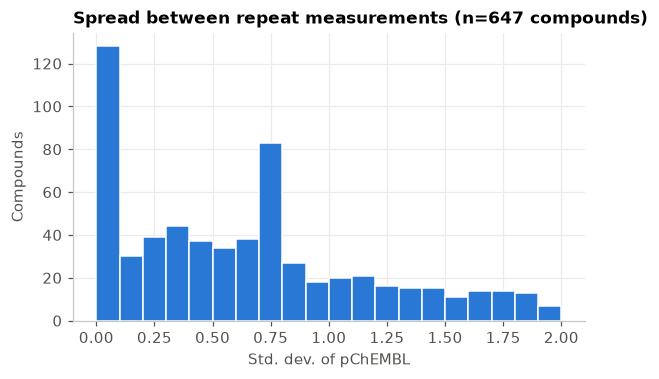

Median std: 0.66
Std > 1 log unit: 169 compounds (26.1%)


In [8]:
multi = compounds[compounds["n_measurements"] > 1]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(multi["pchembl_std"], bins=np.arange(0, 2.05, 0.1),
        color=BLUE, edgecolor="white", linewidth=1)
ax.set_title(f"Spread between repeat measurements (n={len(multi)} compounds)")
ax.set_xlabel("Std. dev. of pChEMBL")
ax.set_ylabel("Compounds")
save(fig, "02_measurement_spread")
plt.show()

print(f"Median std: {multi['pchembl_std'].median():.2f}")
print(f"Std > 1 log unit: {(multi['pchembl_std'] > 1).sum()} compounds "
      f"({(multi['pchembl_std'] > 1).mean():.1%})")

### Binned values

The histogram above has sharp spikes at pChEMBL ≈ 7.26, 8.26, 9.22 and 9.52. Those correspond to exact values of
55, 5.5, 0.6 and 0.3 nM repeated hundreds of times. That pattern means potency was reported as a range
(e.g. "1–10 nM") and stored as a single representative value, rather than measured to that precision.
Below, any document with at least 20 records and at most 5 distinct values is flagged as binned.

In [9]:
# flag_binned is the pipeline's own rule, imported so the notebook cannot drift from it
sys.path.insert(0, str(ROOT / "src"))
from process_activities import flag_binned

records["binned"] = flag_binned(records)
n_binned_docs = records.loc[records["binned"], "document_chembl_id"].nunique()

print(f"Binned documents: {n_binned_docs} of {records['document_chembl_id'].nunique()}")
print(f"Binned records:   {records['binned'].sum()} of {len(records)} "
      f"({records['binned'].mean():.0%})")
print("\nMost common values in binned documents (nM):")
print(records.loc[records["binned"], "standard_value"].value_counts().head(6).to_string())

# binned_only comes straight from the processed table built by process_activities.py
print(f"\nCompounds with only binned values: {compounds['binned_only'].sum()} "
      f"({compounds['binned_only'].mean():.0%})")

Binned documents: 15 of 266
Binned records:   2521 of 6880 (37%)

Most common values in binned documents (nM):
standard_value
0.60     635
5.50     538
0.30     326
55.00    237
50.00    191
0.55     161

Compounds with only binned values: 2330 (39%)


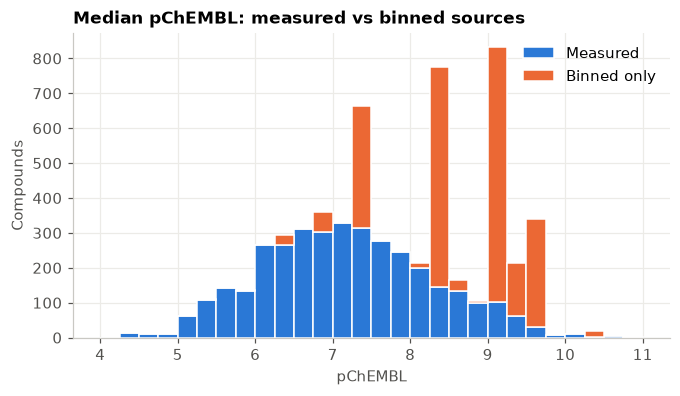

binned_only  False  True   All
domain                        
JH1            197   209   406
JH2            386  1575  1961
Other         3000   546  3546
All           3583  2330  5913


In [10]:
fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.arange(4, 11.25, 0.25)
groups = {"Measured": ~compounds["binned_only"], "Binned only": compounds["binned_only"]}
ax.hist([compounds.loc[m, "pchembl_median"] for m in groups.values()], bins=bins,
        stacked=True, color=[BLUE, ORANGE], label=list(groups), edgecolor="white", linewidth=1)
ax.set_title("Median pChEMBL: measured vs binned sources")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Compounds")
ax.legend()
save(fig, "02_binned_values")
plt.show()

print(pd.crosstab(compounds["domain"], compounds["binned_only"], margins=True))

## 4. Physicochemical properties

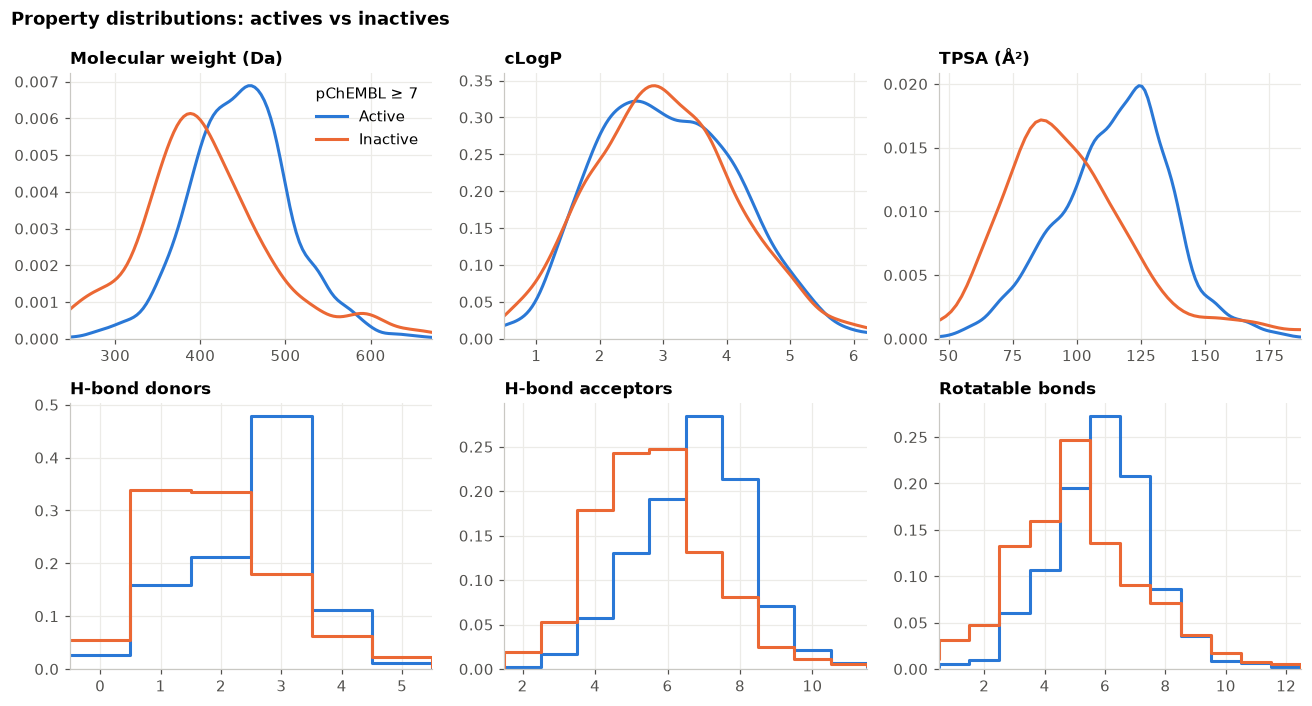

,mw,logp,tpsa,hbd,hba,rot_bonds
activity_class,,,,,,
Active,448.5,3.0,116.8,3.0,7.0,6.0
Inactive,397.6,3.0,93.1,2.0,6.0,5.0


In [11]:
props = {
    "mw": "Molecular weight (Da)",
    "logp": "cLogP",
    "tpsa": "TPSA (Å²)",
    "hbd": "H-bond donors",
    "hba": "H-bond acceptors",
    "rot_bonds": "Rotatable bonds",
}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, (col, label) in zip(axes.flat, props.items()):
    discrete = col in ("hbd", "hba", "rot_bonds")
    lo, hi = compounds[col].quantile([0.005, 0.995])
    for cls in ["Active", "Inactive"]:
        vals = compounds.loc[compounds["activity_class"] == cls, col]
        if discrete:  # integer counts: step histogram, not a smoothed curve
            sns.histplot(vals, ax=ax, discrete=True, stat="density", element="step",
                         fill=False, color=ACTIVITY_COLORS[cls], linewidth=2, label=cls)
        else:
            sns.kdeplot(vals, ax=ax, color=ACTIVITY_COLORS[cls], linewidth=2, label=cls)
    ax.set_xlim(lo - (0.5 if discrete else 0), hi + (0.5 if discrete else 0))
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes.flat[0].legend(title=f"pChEMBL ≥ {ACTIVE_THRESHOLD:g}")
fig.suptitle("Property distributions: actives vs inactives", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
save(fig, "02_property_distributions")
plt.show()

compounds.groupby("activity_class")[list(props)].median().round(1)

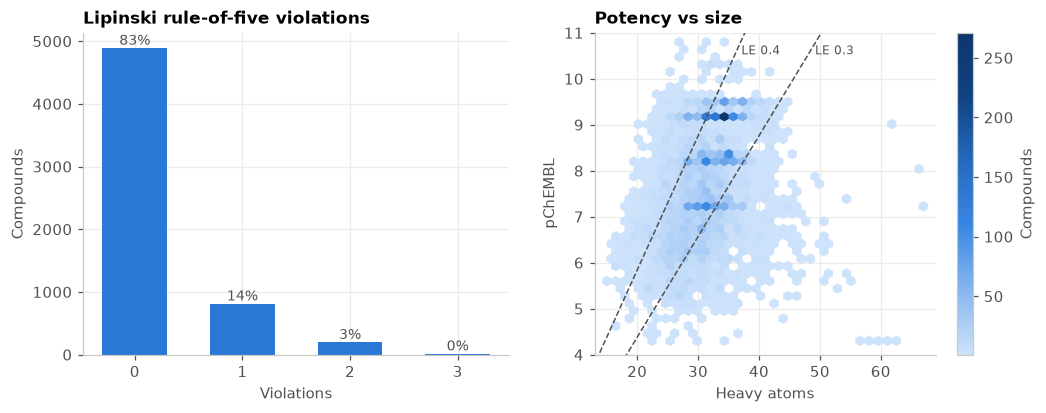

Median ligand efficiency: 0.34


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
viol = compounds["lipinski_violations"].value_counts().sort_index()
ax.bar(viol.index, viol.values, color=BLUE, width=0.6)
for x, y in zip(viol.index, viol.values):
    ax.text(x, y, f"{y / viol.sum():.0%}", ha="center", va="bottom", color=TEXT_2, fontsize=9)
ax.set_xticks(viol.index)
ax.set_title("Lipinski rule-of-five violations")
ax.set_xlabel("Violations")
ax.set_ylabel("Compounds")

ax = axes[1]
hb = ax.hexbin(compounds["heavy_atoms"], compounds["pchembl_median"],
               gridsize=35, cmap=POTENCY_CMAP, mincnt=1, linewidths=0.2)
ax.set_ylim(4, 11)
x = np.linspace(10, 70, 50)
for le in (0.3, 0.4):
    ax.plot(x, le * x / 1.37, color=TEXT_2, linestyle="--", linewidth=1)
    x_top = 10.6 * 1.37 / le  # where the line meets the top of the plot
    ax.text(x_top + 0.8, 10.6, f"LE {le}", color=TEXT_2, fontsize=8, va="center")
ax.set_xlim(compounds["heavy_atoms"].min() - 2, compounds["heavy_atoms"].max() + 2)
ax.set_title("Potency vs size")
ax.set_xlabel("Heavy atoms")
ax.set_ylabel("pChEMBL")
fig.colorbar(hb, ax=ax, label="Compounds")
save(fig, "02_druglikeness")
plt.show()

print(f"Median ligand efficiency: {compounds['ligand_efficiency'].median():.2f}")

## 5. Scaffold analysis

Bemis–Murcko scaffolds (ring systems + linkers, side chains removed) show how many distinct chemical series are in the data.

In [13]:
def murcko(smi):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(smiles=smi)
    except Exception:
        return None

compounds["scaffold"] = compounds["smiles_std"].map(murcko)
scaf = (
    compounds[compounds["scaffold"].fillna("") != ""]
    .groupby("scaffold")
    .agg(n=("pchembl_median", "size"),
         median_pchembl=("pchembl_median", "median"),
         pct_active=("active", "mean"),
         top_domain=("domain", lambda s: s.value_counts().index[0]))
    .sort_values("n", ascending=False)
)
print(f"Unique scaffolds: {len(scaf)}  "
      f"({len(scaf) / len(compounds):.2f} per compound)")
print(f"Singleton scaffolds: {(scaf['n'] == 1).sum()}")
print(f"Compounds covered by top 20 scaffolds: {scaf['n'].head(20).sum() / len(compounds):.0%}")
scaf.head(15).round(2)

Unique scaffolds: 2128  (0.36 per compound)
Singleton scaffolds: 1305
Compounds covered by top 20 scaffolds: 17%


,n,median_pchembl,pct_active,top_domain
scaffold,,,,
c1cnc2cc(Nc3cc[nH]n3)nc(NC3CC4CCC(C3)N4)c2c1,113,7.30,1.00,Other
c1cc2c(-c3cn[nH]c3)nc(-c3cn[nH]c3)cn2n1,100,7.26,0.54,JH1
c1cc2c(ncn3nnc(C4CCCCC4)c23)[nH]1,92,6.77,0.32,Other
c1ccc(CNc2nc(-c3ccccc3)cc3[nH]ncc23)cc1,67,7.31,0.55,Other
c1cc2c(ncc3ncn(C4CCCCC4)c32)[nH]1,60,7.91,0.92,JH2
O=C1NCc2nc(-c3ccccc3)cc(-n3ccc(N4CCCCC4)n3)c21,59,8.30,1.00,Other
c1cnc2cc(Nc3cc[nH]n3)nc(NC3CC4CCCC(C3)N4)c2c1,58,7.30,1.00,Other
O=C(NC1CCC1)c1cnn2ccc(Nc3cccn(C4CCC4)c3=O)nc12,51,9.22,1.00,JH2
c1ccc(Nc2ccnc(Nc3ccccn3)c2)cc1,48,7.40,0.71,Other


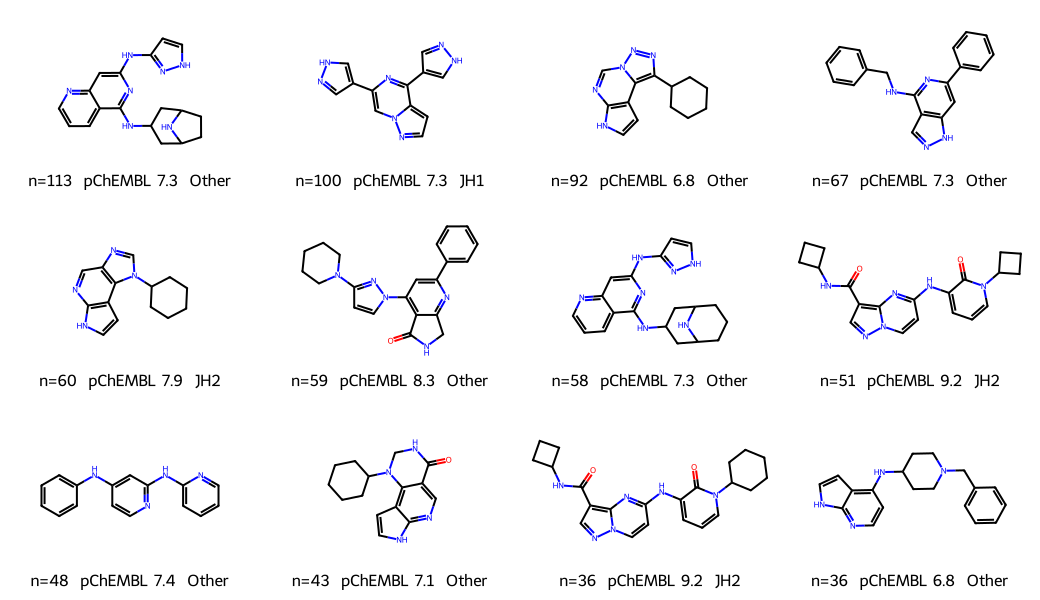

In [14]:
top = scaf.head(12)
img = Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in top.index],
    molsPerRow=4, subImgSize=(260, 200), returnPNG=False,
    legends=[f"n={r.n}  pChEMBL {r.median_pchembl:.1f}  {r.top_domain}"
             for r in top.itertuples()],
)
img.save(FIG_DIR / "02_top_scaffolds.png")
img

## 6. Chemical space

Morgan fingerprints (radius 2, 2048 bits) embedded in 2D with t-SNE on Jaccard (Tanimoto) distance.
Nearby points are structurally similar compounds.

In [15]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = [fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in compounds["smiles_std"]]
X = np.array([np.frombuffer(fp.ToBitString().encode(), "u1") - ord("0") for fp in fps], dtype=bool)

emb = TSNE(n_components=2, metric="jaccard", init="pca", perplexity=40,
           random_state=42).fit_transform(X)
compounds["tsne_1"], compounds["tsne_2"] = emb[:, 0], emb[:, 1]

C:\Users\edwar\GitHub\tyk2-drug-discovery\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2474: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


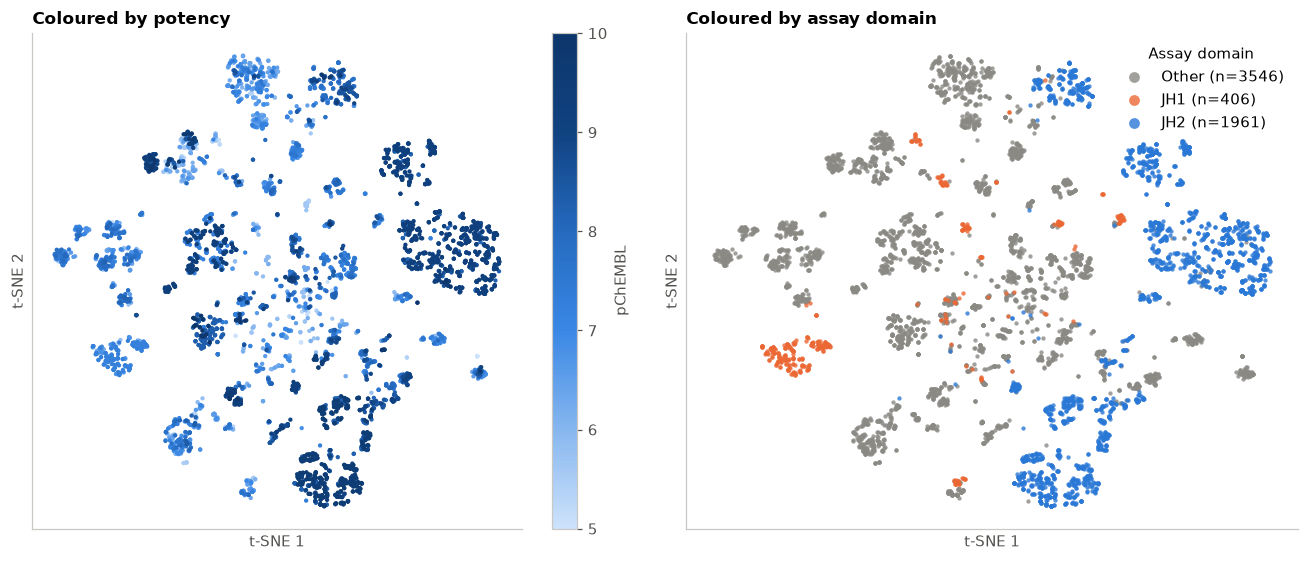

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

ax = axes[0]
order = compounds.sort_values("pchembl_median")
sc = ax.scatter(order["tsne_1"], order["tsne_2"], c=order["pchembl_median"],
                cmap=POTENCY_CMAP, s=8, linewidths=0, vmin=5, vmax=10)
fig.colorbar(sc, ax=ax, label="pChEMBL")
ax.set_title("Coloured by potency")

ax = axes[1]
for dom in ["Other", "JH1", "JH2"]:  # draw the smaller groups on top
    sub = compounds[compounds["domain"] == dom]
    ax.scatter(sub["tsne_1"], sub["tsne_2"], s=8, linewidths=0, alpha=0.8,
               color=DOMAIN_COLORS[dom], label=f"{dom} (n={len(sub)})")
ax.legend(title="Assay domain", markerscale=2.5, loc="best")
ax.set_title("Coloured by assay domain")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
fig.tight_layout()
save(fig, "02_chemical_space")
plt.show()

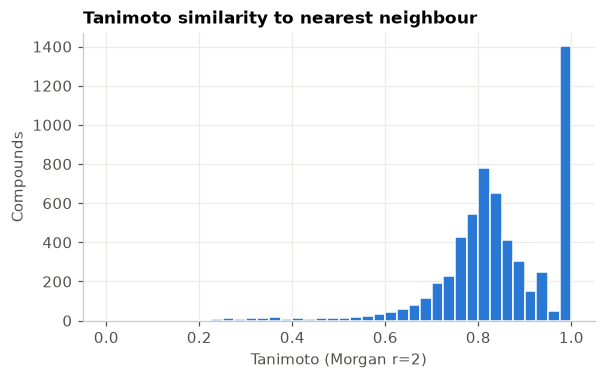

Median NN similarity: 0.83
Compounds with a neighbour at ≥ 0.7: 91%


In [17]:
# Nearest-neighbour similarity: how redundant is the dataset?
nn_sim = np.array([
    sorted(DataStructs.BulkTanimotoSimilarity(fp, fps), reverse=True)[1] for fp in fps
])
compounds["nn_tanimoto"] = nn_sim

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(nn_sim, bins=np.arange(0, 1.025, 0.025), color=BLUE, edgecolor="white", linewidth=1)
ax.set_title("Tanimoto similarity to nearest neighbour")
ax.set_xlabel("Tanimoto (Morgan r=2)")
ax.set_ylabel("Compounds")
save(fig, "02_nearest_neighbour")
plt.show()

print(f"Median NN similarity: {np.median(nn_sim):.2f}")
print(f"Compounds with a neighbour at ≥ 0.7: {(nn_sim >= 0.7).mean():.0%}")

## 7. Summary

**Dataset.** 6,880 activity records covering 5,913 unique compounds from 266 documents. The field is young:
about 75% of compounds were first reported in 2018 or later, with a peak in 2019–2022 driven by JH2 (allosteric) work.

**Data quality: binned values are the big caveat.** 15 documents (probably patent extractions) report potency as
ranges stored as single values (0.3, 0.6, 5.5, 55 nM…). They account for 37% of records and 39% of compounds,
and for **80% of JH2 compounds**. The sharp JH2 peaks at pChEMBL 8.3 and 9.2 are therefore reporting artefacts,
not real structure in the data. Measured-only values form a smooth distribution centred around pChEMBL 7.
Where the same compound was measured more than once, repeat measurements differ by a median of 0.66 log units (≈ the usual ChEMBL noise level),
and 26% differ by more than 1 log unit.

**Chemistry.** 83% of compounds pass Lipinski's rules; median ligand efficiency is 0.34. Actives are larger and more
polar than inactives (median MW 449 vs 398 Da, TPSA 117 vs 93 Å², one extra H-bond donor), with no difference in cLogP.
JH1 and JH2 compounds occupy separate regions of chemical space: the two binding sites favour different chemotypes.

**Structure of the dataset.** 2,128 Murcko scaffolds, 1,305 of them singletons; the top 20 cover only 17% of compounds.
But within series, compounds are near-duplicates: the median nearest-neighbour Tanimoto is 0.83, and 91% of compounds
have a neighbour at ≥ 0.7. It's a set of many tight congeneric series.

**Implications for modelling**
1. Handle binned values explicitly: exclude them for regression, or use them only for classification at a cut-off
   that doesn't fall inside a bin (e.g. pChEMBL 7 sits between the 5.5 and 55 nM bins).
2. Don't use random train/test splits. Near-duplicate neighbours will inflate performance, so use scaffold- or cluster-based splits.
3. Consider separate JH1 and JH2 models, or domain as a feature, since the chemotypes and potency ranges differ.
4. The 0.66 log-unit measurement noise sets a realistic ceiling: an RMSE much below ~0.6 is unlikely to be real.